In [1]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings
from pydantic import BaseModel

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
import re

load_dotenv()

C:\Users\Mirha\AppData\Local\Temp\ipykernel_22460\2565965220.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
c:\Users\Mirha\Personal\AI Engineering\RAGs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
# 1)loading
docs = (
    PyPDFLoader("./documents/book1.pdf").load() +
    PyPDFLoader("./documents/book3.pdf").load()
)
len(docs)

1322

In [3]:
# 2) chunking
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# 3) Clean text to avoid UnicodeEncodeError , to replace weird characters from pdf and run error free
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [4]:
len(chunks)

4117

In [5]:
# 4) embeddings & vector store & retriver
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_store = Chroma.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_type='similarity' ,search_kwargs={'k':4})

c:\Users\Mirha\Personal\AI Engineering\RAGs\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mirha\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9162.72it/s]


In [6]:
# llm
llm = ChatGroq(model="llama-3.1-8b-instant")

In [7]:
class State(TypedDict):
    question : str
    docs : list[Document]

    # ⭐
    good_docs: list[Document]
    verdict : str
    reason : str


    strips : list[str]      #decomposition output (sentences strips)
    kept_strips : list[str] #sentences to keep 
    refined_context : str   #knowledge internal (K internal)     

    answer : str

In [8]:
#node 1
def retrieves_docs(state:State) -> State:
    question = state['question']
    return {'docs': retriever.invoke(question)}

In [11]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [ ]:
# node 2 (new NODE ⭐) 
# -----------------------------
# Score-based doc evaluator
# -----------------------------
class DocEvalScore(BaseModel):
    score: float
    reason: str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)


#---------------------------------------------------------------
#  main document evaluation node ⭐
# --------------------------------------------------------------- 
def docs_evaluation(state: State) -> State:
    q = state['question']

    scores: list[float] = []
    reasons: list[str] = []
    good_docs: list[Document] = []

    for d in state['docs']:
        out = doc_eval_chain.invoke({'question':q, 'chunk': d})
        scores.append(out.score)
        reasons.append(out.reason)


        if out.score > LOWER_TH:
            good_docs.append(d)

    # correct condition
    if any(s>UPPER_TH for s in scores):
        return{
            "good_docs": good_docs,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # incorrect condition
    if len(scores)>0 and all(s<LOWER_TH for s in scores):
        why = "chunks were irrelevant"
        return{
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}. {why}"
        }
    
    # ambiguous condition 
    why = "retrived chunks were ambiguous"
    return{
        "good_docs": [],
        "verdict": "AMBIGUOUs",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}"
    }



In [13]:
# node 3

# -----------------------------
# 1st part Sentence-level DECOMPOSER  (will split paragraph into list of sentences )
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

class keeporDROP(BaseModel):
    keep : bool

filter_prompt = ChatPromptTemplate([
    ("system",
    "You are a strict relevance filter.\n"
    "Return keep=true only if the sentence directly helps answer the question.\n"
    "Use ONLY the sentence. Output JSON only."),
    ("user","Question: {question}\n\nSentence:\n{sentence}")
])
# 2nd part

filter_chain = filter_prompt | llm.with_structured_output(keeporDROP)

# -------------------------------------------------------------------------------------
# REFINING (Decompose -> Filter -> Recompose)  
# -------------------------------------------------------------------------------------
def refine(state: State) -> State:

    q = state["question"]

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state['good_docs']).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []
    
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }


In [14]:
#node 3
prompt = ChatPromptTemplate([
    ("system",
    "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
    "If the bullets are empty or insufficient, say: 'I don't know based on the provided books."),
    ("user","Question: {question}\n\nRefined context:\n{refined_context}")
])

def generate(state:State) -> State:
    context = "\n\n".join(d.page_content for d in state['docs'])
    out = (prompt | llm).invoke({'question':state['question'],'refined_context':state['refined_context']}).content
    return {'answer':out}

In [16]:
def incorrect_node(state:State) -> State:
    return {'answer': f"FAIL: {state['reason']}"}


def ambiguous_node(state:State) -> State:
    return {'answer':f"Ambiguoug : {state['reason']}"}

def route_condition(state:State) -> str:
    if state['verdict'] == "CORRECT":
        return "correct"
    elif state['verdict']== "INCORRECT":
        return "incorrect"
    else:
        return "ambiguous"
    

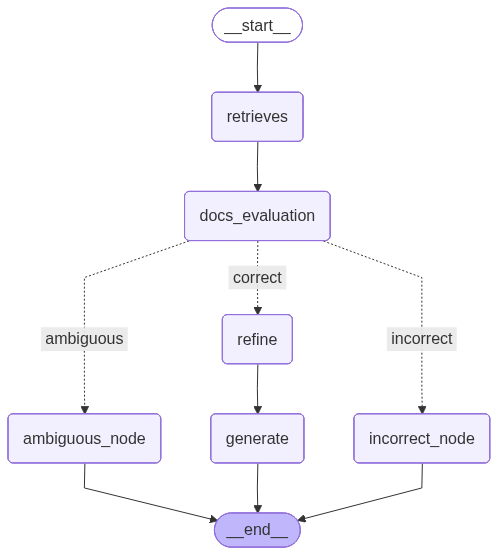

In [17]:
graph = StateGraph(State)

graph.add_node('retrieves',retrieves_docs)
graph.add_node('docs_evaluation',docs_evaluation)
graph.add_node('incorrect_node',incorrect_node)
graph.add_node('ambiguous_node',ambiguous_node)
graph.add_node('refine',refine)
graph.add_node('generate',generate)

graph.add_edge(START,'retrieves')
graph.add_edge('retrieves','docs_evaluation')
graph.add_conditional_edges('docs_evaluation',route_condition,
                            {"correct":"refine","incorrect":"incorrect_node","ambiguous":"ambiguous_node"})
graph.add_edge('refine','generate')
graph.add_edge('generate',END)

graph = graph.compile()

graph

In [24]:
result = graph.invoke(
    {
        "question": "What are attention mechanisms and why are they important in llm?",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "answer": "",
    }
)

print("VERDICT:", result["verdict"])
print("REASON:", result["reason"])
print("\nOUTPUT:\n", result["answer"])

VERDICT: AMBIGUOUs
REASON: No chunk scored > 0.7, but not all were < 0.3. retrived chunks were ambiguous

OUTPUT:
 Ambiguoug : No chunk scored > 0.7, but not all were < 0.3. retrived chunks were ambiguous
